# Driven Radial Diffusion in 3D (radial geometry)

What is the concentration profile $c(r)$ if particles are injected at $r=r_0$ with current density $j_0$ and at $r=R$ the particles are removed into the bulk at concentration $c_0$, assuming steady state, i.e., $\frac{\partial c}{\partial t} = 0$?

We assume Fick's law for the current

$$
j = -D \nabla c
$$

with the diffusion coefficient $D$. For simplicity, we will assume that $D$ is constant and does not depend on position.

The concentration $c(t, \mathbf{r})$ obeys the diffusion equation 
\begin{equation}
\frac{\partial c}{\partial t} = D\nabla^2 c
\end{equation}
without sources or sinks. (Note that we will be injecting protons on the _boundary_ of the problem, so no sources, and protons will leave at the other boundary, so no sinks.)

We are looking for the steady state


$$
\frac{\partial c}{\partial t} = 0
$$

so there will no time dependence, $c(z)$, and we will solve Laplace's equation
$$
\nabla^2 c = 0
$$

## Spherical geometry

### Simplifying model assumptions
We assume a spherical geometry where we do not take the membrane into account. Effectively, we assume that protons emitted at the outward facing proton binding site of NHE6 (of radius $r_0$) can then freely diffuse away in any direction. 

Our goal is to get a rough idea how proton concentration may change as a function of distance from the emission site.

In particular, we will investigate the role of reduced diffusion for protons.


### Solution of the diffusion problem
In spherical coordinates with radial symmetry (no angular dependence due to symmetry), Laplace's equation becomes:

$$\nabla^2 c = \frac{1}{r^2}\frac{d}{dr}\left(r^2\frac{dc}{dr}\right) = 0$$

This simplifies to:
$$\frac{d}{dr}\left(r^2\frac{dc}{dr}\right) = 0$$

### Boundary conditions

The problem has two boundary conditions:

1. **Particle emission at r = r₀**: The gradient condition represents a constant flux density of particles being emitted from the inner sphere:
   $$\left.\frac{\partial c}{\partial r}\right|_{r=r_0} = -\frac{j_0}{D}$$
   
   where $j_0$ is the particle flux density and $D$ is the diffusion coefficient. The total proton emission rate is the integral of $j_0$ over the sphere with radius $r_0$ (i.e., the turnover number of the proton transporter, in protons per unit time):
   $$k_0 = 4\pi r_0^2 j_0$$
   
   Therefore: $j_0 = \frac{k_0}{4\pi r_0^2}$

2. **Absorbing boundary at r = R**: The outer boundary maintains a constant concentration:
   $$c(r=R) = c_0$$

### Solution

Integrating Laplace's equation once:
$$r^2\frac{dc}{dr} = A$$

where $A$ is a constant of integration. Therefore:
$$\frac{dc}{dr} = \frac{A}{r^2}$$

Integrating again:
$$c(r) = -\frac{A}{r} + B$$

where $B$ is the second constant of integration.

### Applying boundary conditions

From the absorbing boundary condition at $r = R$:
$$c_0 = -\frac{A}{R} + B$$
$$B = c_0 + \frac{A}{R}$$

From the flux boundary condition at $r = r_0$:
$$\frac{dc}{dr}\bigg|_{r=r_0} = \frac{A}{r_0^2} = -\frac{j_0}{D}$$

Therefore:
$$A = -\frac{j_0 r_0^2}{D}$$

Substituting back for $B$:
$$B = c_0 + \frac{A}{R} = c_0 - \frac{j_0 r_0^2}{DR}$$

### Final solution

The concentration profile is:
$$c(r) = -\frac{A}{r} + B = c_0 + \frac{j_0 r_0^2}{D}\left(\frac{1}{r} - \frac{1}{R}\right)$$

Expressing in terms of the total proton emission rate $k_0 = 4\pi r_0^2 j_0$:
$$c(r) = c_0 + \frac{k_0}{4\pi D}\left(\frac{1}{r} - \frac{1}{R}\right)$$

This solution shows that:
- The concentration decreases monotonically from the inner sphere ($r = r_0$) to the outer boundary ($r = R$)
- At $r = r_0$: $c(r_0) = c_0 + \frac{k_0}{4\pi D}\left(\frac{1}{r_0} - \frac{1}{R}\right)$
- At $r = R$: $c(R) = c_0$ (satisfies boundary condition)
- The concentration profile has a $1/r$ dependence, characteristic of spherical diffusion
- The solution depends on the total emission rate $k_0$ rather than the flux density $j_0$ 




The solution for emission into the half-space $z>0$ looks identical (except that $c=0$ in the lower half space) and we only have to interpret $k_0$ as the emission rate into the half space.

## Methods

We use `sympy` to work with the equations:

In [1]:
import sympy as sm
import scipy
import numpy as np
import matplotlib.pyplot as plt

In [2]:
r, k, c0, D, R, j0, k0, r0 = sm.symbols("r,k,c_0,D,R,j_0,k_0,r_0")
N_A, n, x = sm.symbols("N_A, n, x")

Analytical solution

In [3]:
c = c0 + k0/(4* sm.pi *D) * (1/r - 1/R)
c

c_0 + k_0*(1/r - 1/R)/(4*pi*D)

### Increased figure resolution
When outputting figures as PNG (e.g., when exporting the notebook to PDF via LaTeX) we want to set the resolution to at least 300 dpi; however, for working in the notebook, this is not convenient as the figures show up to large.

In [4]:
#%matplotlib inline
#import matplotlib as mpl
#mpl.rcParams['figure.dpi'] = 300

On modern displays, you can always enable higher resolution display figures (can be done in addition to the dpi increase).

In [5]:
%config InlineBackend.figure_format = 'retina'

### Functions

For convenience, we define functions to set up the solution with ranges of specific parameters.

* `solve_c()`: return equations with numerical values for parameters (in particular, $k$)
* `plot_c()`: solve equations and then plot concentration $c(z)$ and local pH profile for a given parameter set as given as keyword arguments
* `plot_range()`: solve and plot a *quantity* (either `"c"` or `"pH"`) for a range of values for a specific *parameter*

In [6]:
import sympy as sm
import scipy

# conversions
x, n, pH, N_A = sm.symbols("x, n, pH, N_A")
fromMolar = x * N_A / 1e24
toMolar = n / N_A * 1e24
from_pH = fromMolar.subs(x, 10**(-pH))
to_pH = -sm.log(toMolar, 10)

constants = {N_A: scipy.constants.Avogadro}


def solve_c(R_nm=9, bulk_pH=7.2, k_proton=1, D_proton=9.3e-3, double_rate=False):
    N_A = sm.symbols("N_A")
    r, c0, D, R, j0 = sm.symbols("r,c_0,D,R,j_0")
    kH, rH, pH = sm.symbols("k_H, r_H, pH")
    constants = {N_A: scipy.constants.Avogadro}

    # use if we lump both protomers into a single emission site
    rate_factor = 1 if not double_rate else 2

    proton_transport = {kH: k_proton * 1e-9 * rate_factor,   # proton transport rate in ms^-1, convert to ps
                        rH: 0.3, # radius of exit pathway
                        pH: bulk_pH,   # bulk solution pH
                       }

    parameters = {R: R_nm, 
                  j0: kH/(4 * sm.pi * rH**2), # not used in the solution
                  c0: from_pH,       # pH -> c0
                  D: D_proton,       # proton diffusion coefficient
              }   

    c = c0 + kH/(4 * sm.pi * D) * (1/r - 1/R)

    concentration_z = {
        "func": toMolar.subs(n, c.subs(parameters)
                  .subs(proton_transport))
                  .subs(constants),
        "range": (r, rH.subs(parameters).subs(proton_transport), R.subs(parameters)),
        }
    pH_z = {
        "func": to_pH.subs(n, c.subs(parameters)
                                .subs(proton_transport))
                                .subs(constants),
        "range": (r, rH.subs(parameters).subs(proton_transport), R.subs(parameters)),
        }
    return concentration_z, pH_z

    
def plot_c(**kwargs):
    c_r, pH_r = solve_c(**kwargs)

    sm.plotting.plot(c_r["func"], c_r["range"],
                     xlabel=r"$r$ (nm)", ylabel=r"$c(r)$ (mol/l)", size=(3,3))
    sm.plotting.plot(pH_r["func"], pH_r["range"],
                     xlabel=r"$r$ (nm)", ylabel=r"pH$(r)$", size=(3,3))
    

def plot_range(parameter, parameter_range, 
               quantity="pH",
               size=(4, 3),
               save=True,
               legend=True,
               **kwargs):
    pix = {'c': 0, 'pH': 1}   # index with quantity
    plabel = {'c': r"$c(r)$ (mol/l)", 'pH': r"pH$(r)$"}
    parameter_labels = {
        "k_proton": r"$k_{{\mathrm{{H}}^+}}={value}$ ms$^{{-1}}$",
        "R_nm": r"$R={value}$ nm",
        "bulk_pH": "bulk pH {value}",
        "D_proton": r"$D_{{\mathrm{{H}}^+}}={value:.1e}\,\mathrm{{nm}}^2\cdot\mathrm{{ps}}^{{-1}}$",
    }
    if save:
        filename = kwargs.pop("filename", 
                              f"protondiffusion_spherical_{quantity}_{parameter}.pdf")
    show = not save
    
    kw = kwargs.copy()
    functions = []
    label = []
    for value in parameter_range:
        kw[parameter] = value
        solution = solve_c(**kw)
        p = solution[pix[quantity]]
        functions.append((p["func"], p["range"]))
        label.append(parameter_labels[parameter].format(value=value))
    p1 = sm.plotting.plot(*functions,
                     xlabel=r"$r$ (nm)", ylabel=plabel[quantity], 
                     label=label, legend=legend,
                     show=show, 
                     size=size)
    if save:
        p1.save(filename)
        print(f"Saved to {filename}")
    return p1    


# Results: Concentration profile with realistic parameters

units: nm, ps 

Convert mol to numbers by multiplying with $N_A$

* Unit of $j_0$ is $\text{time}^{-1}\, \text{length}^{-2}$.
* Unit of $D$ is $\text{length}^{2}\, \text{time}^{-1}$.

| parameter | value | value (nm, ps)     |
|-----------|-------|--------------------|
|    $c_0$  | pH 7.2  |  $2.3326612721888007 \times 10^{-8}\,\mathrm{nm}^{-3}$|
| $D_{H^+}$ | $7000\ \text{µm}^2/\text{s}$ | $7 \times 10^{-3} \text{nm}^2/\text{ps}$ |
| $D_{H^+}$ | $9.3 \times 10^{-5}\ \text{cm}^2/\text{s}$ | $9.3 \times 10^{-3} \text{nm}^2/\text{ps}$ |
| $D_\mathrm{eff}$ | $D_{H^+} / 10^{4}$ | $9.3 \times 10^{-7} \text{nm}^2/\text{ps}$ |
| $R$       | 9 nm  |   9 nm             |
| $r_0$       | 3 Å  |   0.3 nm             |
| $k_{\mathrm{H}^+}$ | 1 $\mathrm{ms}^{-1}$ | $1\times 10^{-9}\,\mathrm{ps}^{-1}$ |

pH: Theillet FX et al., Physicochemical properties of cells and their effects on intrinsically disordered proteins (IDPs). Chem Rev. 2014 Jul 9 114(13):6661-714. doi: 10.1021/cr400695p p.6663 (via [bionumbers 115761](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=115761)

Proton diffusion coefficient: 

* 7000 µm $^2$/sec (from [BioNumbers ID 106702](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=106702)) = $7 \times 10^3 (10^3 \text{nm})^2 / 10^{12} \text{ps} = 7 \times 10^{-3} \text{nm}^2/\text{ps}$ 
* $9.3\times 10^{-5}\ \text{cm}^2/\text{s}$ from Lee et al manuscript (extended data)
  

Specific model parameters and assumptions (see below for details)

* protons diffuse through a spherical volume and encounter bulk at $R=9\,\mathrm{nm}$ and bulk pH is 7.2; 
* protons diffuse at the reduced effective diffusion coefficient $D_\mathrm{eff} = D_{H^+} / 10^{4}$
* the His 207 residue is located at about $r=7.5\,\mathrm{nm}$ 
* the system is in steady state (i.e., the influx of protons into the tunnel due to NHE6 equals the efflux of protons at the surface of the sphere at $R$)

### Simplified spherical proton "path" model for TBC1D5/Rab7/NHE6 

Although a possible proton path can be traced from the NHE6 cytosolic exit towards His207 (proton sensor in TBC1D5), we will assume that protons diffuse isotropically into the hemisphere above the proton binding site near D260 (NHE6). 
 

<!--
<img src="figs/TBC1D5_Rab7_NHE6_diffusion_sphere_centered.jpg" alt="Spherical geometry in TBC1D5/Rab7/NHE6, leading from D260 to H207" style="width: 30%;">
-->

![Spherical geometry in TBC1D5/Rab7/NHE6, leading from D260 to H207](figs/TBC1D5_Rab7_NHE6_diffusion_sphere_centered.jpg)

The dimensions of the spherical geometry are derived from the molecular model:

- Bulk "far" away $R=9$ nm
- ionizable residue near $r_\mathrm{H207}=7.5$ nm
- emission hemisphere $r_0=0.3$ nm

We will assume that proton diffusion is slowed down by a factor $0 < \alpha \ll 1$, e.g. $\alpha = 10^{-4}$ 

- $D_\mathrm{eff} = \alpha D_{H^+}$

We are making a number of simplifying assumptions:

* Protons encounter an environment with a diffusion coefficient $D = \alpha D_\mathrm{bulk}$ that is reduced by a factor $0 < \alpha \ll 1$ compared to the bulk value. The assumption is that protons diffuse through a network of passageways in the protein complex but we don't know the exact paths. To keep the model simple, this reduction applies throughout the whole hemisphere (regardless if the hemisphere is overlapping with lipids or cytosolic solution).
* For mathematical convenience, we model the emission site surface as a small hemisphere at the center of the NHE6 dimer. Effectively we are treating the proton production of both dimers as a single emission site. Thus, we *double the emission rate* $k_H$.
* At the outer spherical boundary $R$ nm, the pH has the bulk value 7.2 because of the presence of buffer molecules.
* the His 207 residue is located at a distance of about $r_\mathrm{H207}=7.5\,\mathrm{nm}$ from the emission site
* the system is in steady state (i.e., the influx of protons into the tunnel due to NHE6 equals the efflux of protons at the exit of the tunnel)

#### Transport without thermodynamic limitation

Saved to protondiffusion_spherical_R=9nm.pdf


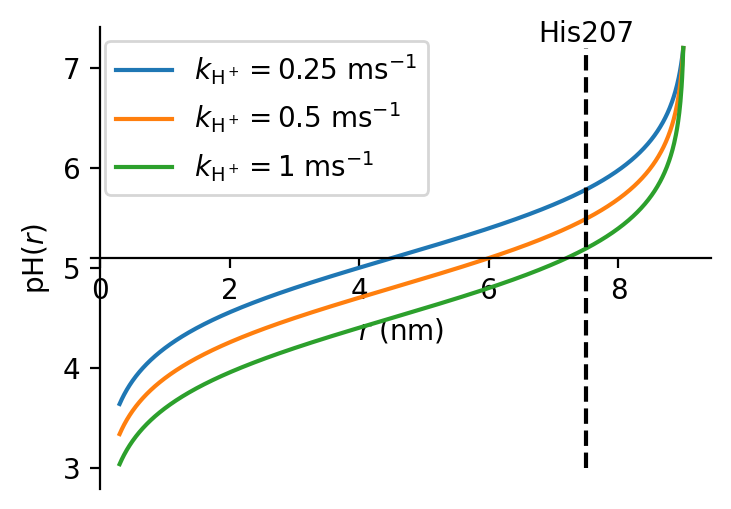

In [7]:
alpha = 1e-4
bulk_pH = 7.2
Rmax = 9
D_proton_bulk = 9.3e-3
r_His207 = 7.5

filename = f"protondiffusion_spherical_R={Rmax}nm.pdf"
plot_range("k_proton", (0.25, 0.5, 1), R_nm=Rmax, 
           double_rate=True, 
           bulk_pH=bulk_pH, D_proton=alpha * D_proton_bulk,
           filename=filename)
plt.vlines(r_His207, 3, bulk_pH, color="k", linestyle="--")
plt.text(r_His207, bulk_pH, "His207", ha="center", va="bottom")
plt.savefig(filename)


### Transport with limiting concentration

#### Physiological concentrations and driving forces

For the late endosome and the cytosol, pH and ion concentrations are:

| ion | inside (late endosome) | outside (cytosol) | reference |
|-----|-------------------|-------------------|-----------|
| Na<sup>+</sup> | 20 - 140 mM        | ~12 mM          | Haoxing Xu and Dejian Ren, Lysosomal Physiology, Annu. Rev. Physiol. 2015. 77: 57–80 doi: [10.1146/annurev-physiol-021014-071649](https://doi.org/10.1146/annurev-physiol-021014-071649) via [bionumbers 117096](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=117096)   |
| K<sup>+</sup>  | 2 - 50 mM        | ~150 mM             | Haoxing Xu and Dejian Ren, Lysosomal Physiology, Annu. Rev. Physiol. 2015. 77: 57–80 doi: [10.1146/annurev-physiol-021014-071649](https://doi.org/10.1146/annurev-physiol-021014-071649) via [bionumbers 117096](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=117096)|
| H<sup>+</sup>  | pH 5.5-5.8        | pH 7.2             | Ma L, Ouyang Q, Werthmann GC, Thompson HM and Morrow EM (2017) Live-cell Microscopy and Fluorescence-based Measurement of Luminal pH in Intracellular Organelles. Front. Cell Dev. Biol. 5:71. doi: [10.3389/fcell.2017.00071](https://doi.org/10.3389/fcell.2017.00071); Theillet FX et al., Physicochemical properties of cells and their effects on intrinsically disordered proteins (IDPs). Chem Rev. 2014 Jul 9 114(13):6661-714. doi: [10.1021/cr400695p](https://doi.org/10.1021/cr400695p) p.6663 (via [bionumbers 115761](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=115761)) |



In [8]:
# extreme concentrations in mol/l
concentrations = {
    "Na+": {"in": 0.140, "out":0.012}, 
    "K+": {"in": 0.002, "out": 0.150},
    "H+": {"in": 10**(-5.5), "out": 10**(-7.2)}
    }

def driving_force_kT(c_in, c_out):
    """Thermodynamic driving force for a concentration gradient in units of kT"""
    return sm.log(c_in / c_out)

(For discussion about thermodynamic limits, see [Diffusion1D_cylindrical.ipynb](Diffusion1D_cylindrical.ipynb).

#### Concentration profile under kinetic limiting condition 

Sodium/proton antiporter typically display an activity range in which they are active (e.g. pH 6.5 - 9.0). We do not know the activity range of NHE6. We therefore make the assumption that it does not transport below pH 5.5 (which equals the endosomal pH).

In [ ]:
pH_out_min = 5.5

In the following we will also make the simplifying assumption that the transport rate does not depend on the external concentrations of ions/protons. (This is almost certainly not true, see for an example the simplified sodium/proton antiporter in [Kenney & Beckstein 2023](https://pubmed.ncbi.nlm.nih.gov/37638349/) (Fig 7a) where the turnover number is shown to depend on the sodium concentration.) We can the calculate an effective limiting transport rate $k_{0,\mathrm{max}}$  by solving the analytical solution for $c(r=r_H)$ at the limiting concentration $c_\mathrm{max} = 10^{-\mathrm{pH}^\mathrm{out}}$

\begin{equation}
c(r=r_H)  < c_\mathrm{max}
\end{equation}

In [10]:
c

c_0 + k_0*(1/r - 1/R)/(4*pi*D)

In [11]:
c_max, rH, kH = sm.symbols("c_max,r_H,k_H")

eqn = sm.Eq(c.subs({r: rH}), c_max)
k0_max = sm.solve(eqn, k0)[0]
k0_max


4*pi*D*R*r_H*(-c_0 + c_max)/(R - r_H)

We can substitute our particular solution to have the concentration profile as a function of the maximum concentration:

In [12]:
c_clamped = c.subs({k0: k0_max})
c_clamped

R*r_H*(-c_0 + c_max)*(1/r - 1/R)/(R - r_H) + c_0

Note that this concentration profile _does not depend on the diffusion coefficient_. We could have solved the Laplace equation just with the boundary conditions $c(r=r_H) = c_\mathrm{max}$ and $c(z=R) = c_{0}$. Thus, if the transporter is fast enough to generate a local pH at the thermodynamic limit, it does not matter how fast protons diffuse away.

(In the following we, calculate the effective proton transfer rate and plug it into our original solution although we could have also worked with the equation above.)

What would the effective proton transport rate be?

In [18]:
bulk_pH = 7.2
alpha = 1e-4

pH_out_min = 5.5

parameters = {
    R: Rmax,   # nm
    D: alpha * D_proton_bulk, # nm^2/ps
    rH: 0.3,   # nm
    c0: from_pH.subs(pH, bulk_pH).subs(constants),
    c_max: from_pH.subs(pH, pH_out_min).subs(constants)}
    
kH_max = sm.N(k0_max.subs(parameters).subs(constants) / 1e-9, 3) # convert rate in ns^-1 to ms^-1
print(f"kH_max = {kH_max} ms^-1")


kH_max = 0.00677 ms^-1


This is a very small rate, compared to the fast turnover of eg NhaA of ~1 ms $^{-1}$. (And it's also the "double" rate because the model averages over two antiporter subunits, the per-monomer rate is half of the value.)

With this effective proton transport rate (or equivalently, a minimum local pH 5.5 at the cytosolic exit of NHE6), the concentration profile has the following shape. (Note that the diffusion coefficient does not really matter as shown above but in order to re-use our code, we have to use the same diffusion coefficient that we used for calculating the maximum proton current).

In [19]:
kH_max, D_proton_bulk

(0.00677, 0.0093)

Saved to figs/protondiffusion_R=9nm_kHmax.pdf


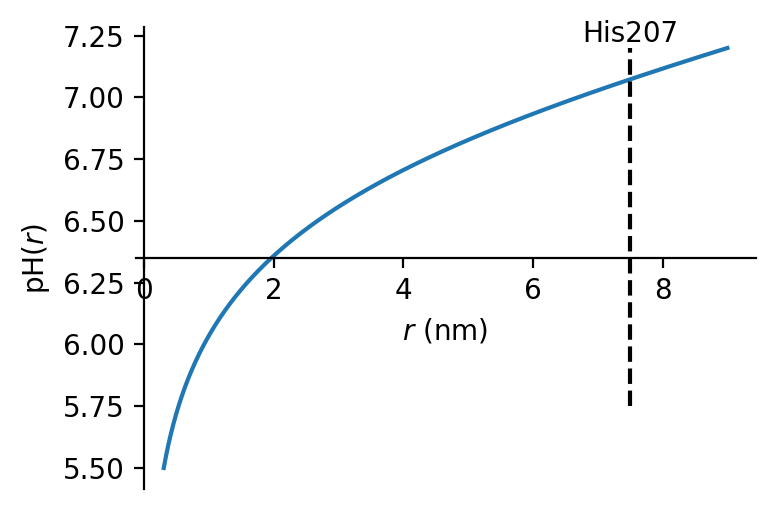

In [20]:
alpha = 1e-4
filename = f"figs/protondiffusion_R={Rmax}nm_kHmax.pdf"
plot_range("k_proton", (kH_max,), R_nm=Rmax, 
           bulk_pH=bulk_pH, D_proton=alpha * D_proton_bulk,
           filename=filename, legend=False, double_rate=False)  # rate is already doubled
plt.vlines(r_His207, 5.75, bulk_pH, color="k", linestyle="--")
plt.text(r_His207, bulk_pH, "His207", ha="center", va="bottom")
plt.savefig(filename)

The lowest pH is 5.5 at $r=r_H$ (by construction) and by assumption, still sufficient to support proton transport. The pH around the position of His207 is close to bulk pH and will not affect its protonation state.

In [21]:
c_His207 = c_clamped.subs(parameters).subs({r: r_His207})

In [22]:
pH_His207 = sm.N(to_pH.subs({n: c_His207}).subs(constants), 3)
print(f"At His207: pH {pH_His207}")

At His207: pH 7.07
